In [1]:
%load_ext hamilton.plugins.jupyter_magic

/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


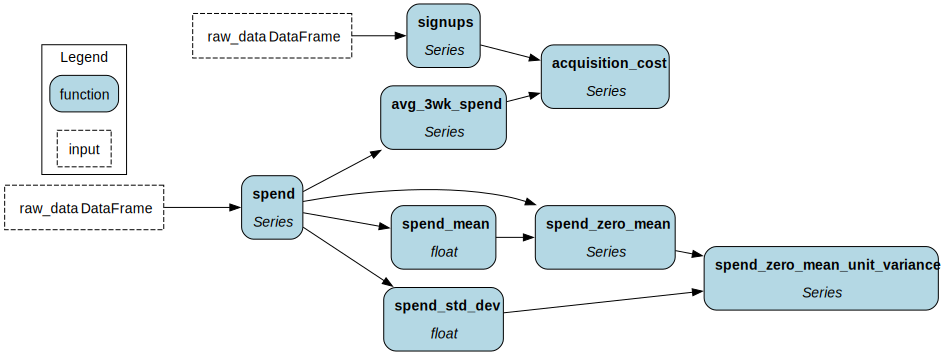

In [10]:
%%cell_to_module -m module1 --display --rebuild-drivers
import polars as pl
import pandas as pd

def spend(raw_data: pd.DataFrame) -> pl.Series:
    """Extract spend column"""
    return pl.from_pandas(raw_data['spend'])

def signups(raw_data: pd.DataFrame) -> pl.Series:
    """Extract signups column"""
    return pl.from_pandas(raw_data['signups'])

def avg_3wk_spend(spend: pl.Series) -> pl.Series:
    """Rolling 3 week average spend."""
    return spend.rolling_mean(window_size=3)

def acquisition_cost(avg_3wk_spend: pl.Series, signups: pl.Series) -> pl.Series:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: pl.Series) -> float:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: pl.Series, spend_mean: float) -> pl.Series:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: pl.Series) -> float:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: pl.Series, spend_std_dev: float) -> pl.Series:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev

In [4]:
import dataclasses
from os import PathLike
from typing import Any, Collection, Dict, Tuple, Type, Union
import polars as pl
from hamilton.io import utils
from hamilton.io.data_adapters import DataLoader


@dataclasses.dataclass
class PolarsMockDataLoader(DataLoader):

    @classmethod
    def applicable_types(cls) -> Collection[Type]:
        return [pl.DataFrame]

    def load_data(self, type_: Type) -> Tuple[pl.DataFrame, Dict[str, Any]]:
        df_input = pl.DataFrame({
            'signups': [1, 10, 50, 100, 200, 400],
            'spend': [10, 10, 20, 40, 40, 50],
        })

        return df_input, {}

    @classmethod
    def name(cls) -> str:
        return "json"  # the name for `from_.{name}`

In [6]:
# Create a driver with the data adapter
from hamilton import driver

# Build driver with data adapter
dr = (
    driver.Builder()
    .with_config({})
    .with_modules(module1)
    .with_adapters(PolarsMockDataLoader())
    .build()
)

# Create the mock data using the loader directly
loader = PolarsMockDataLoader()
raw_data, _ = loader.load_data(pl.DataFrame)

output_columns = [
    'spend',
    'signups', 
    'avg_3wk_spend',
    'acquisition_cost',
    'spend_mean',
    'spend_zero_mean',
    'spend_std_dev',
    'spend_zero_mean_unit_variance'
]

# Execute with the loaded data as input
result = dr.execute(
    output_columns,
    inputs={'raw_data': raw_data}
)

print(result)

{'spend': shape: (6,)
Series: 'spend' [i64]
[
	10
	10
	20
	40
	40
	50
], 'signups': shape: (6,)
Series: 'signups' [i64]
[
	1
	10
	50
	100
	200
	400
], 'avg_3wk_spend': shape: (6,)
Series: 'spend' [f64]
[
	null
	null
	13.333333
	23.333333
	33.333333
	43.333333
], 'acquisition_cost': shape: (6,)
Series: 'spend' [f64]
[
	null
	null
	0.266667
	0.233333
	0.166667
	0.108333
], 'spend_mean': 28.333333333333332, 'spend_zero_mean': shape: (6,)
Series: 'spend' [f64]
[
	-18.333333
	-18.333333
	-8.333333
	11.666667
	11.666667
	21.666667
], 'spend_std_dev': 17.224014243685083, 'spend_zero_mean_unit_variance': shape: (6,)
Series: 'spend' [f64]
[
	-1.064405
	-1.064405
	-0.483821
	0.677349
	0.677349
	1.257934
]}


In [7]:
from hamilton.io.materialization import from_, to

from_.parquet(target="raw_df", path="./parquet")

In [8]:
import pandas as pd

In [9]:
df = pd.DataFrame({
    'signups': [1, 10, 50, 100, 200, 400],
    'spend': [10, 10, 20, 40, 40, 50],
})
df.to_parquet("test.parquet")

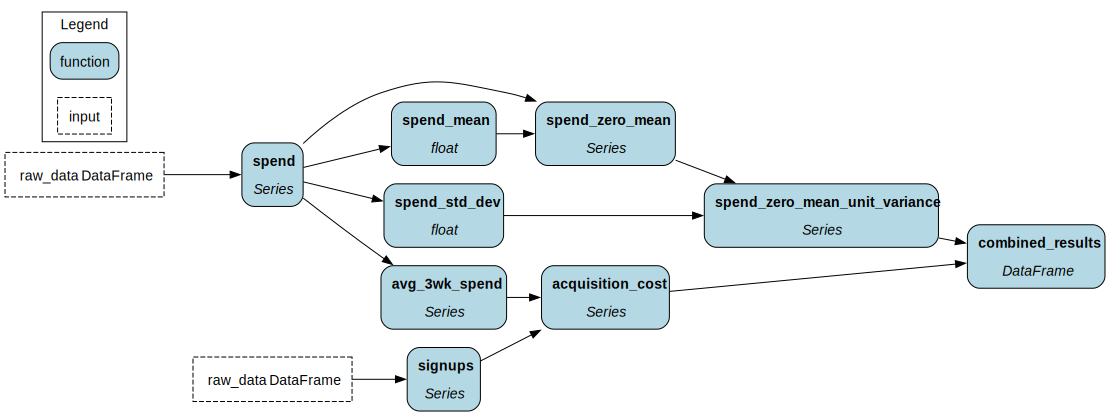

In [15]:
%%cell_to_module -m module1 --display --rebuild-drivers
import polars as pl
import pandas as pd

def spend(raw_data: pd.DataFrame) -> pl.Series:
    """Extract spend column"""
    return pl.from_pandas(raw_data['spend'])

def signups(raw_data: pd.DataFrame) -> pl.Series:
    """Extract signups column"""
    return pl.from_pandas(raw_data['signups'])

def avg_3wk_spend(spend: pl.Series) -> pl.Series:
    """Rolling 3 week average spend."""
    return spend.rolling_mean(window_size=3)

def acquisition_cost(avg_3wk_spend: pl.Series, signups: pl.Series) -> pl.Series:
    """The cost per signup in relation to a rolling average of spend."""
    return avg_3wk_spend / signups

def spend_mean(spend: pl.Series) -> float:
    """Shows function creating a scalar. In this case it computes the mean of the entire column."""
    return spend.mean()

def spend_zero_mean(spend: pl.Series, spend_mean: float) -> pl.Series:
    """Shows function that takes a scalar. In this case to zero mean spend."""
    return spend - spend_mean

def spend_std_dev(spend: pl.Series) -> float:
    """Function that computes the standard deviation of the spend column."""
    return spend.std()

def spend_zero_mean_unit_variance(spend_zero_mean: pl.Series, spend_std_dev: float) -> pl.Series:
    """Function showing one way to make spend have zero mean and unit variance."""
    return spend_zero_mean / spend_std_dev

def combined_results(spend_zero_mean_unit_variance: pl.Series, acquisition_cost:  pl.Series) -> pd.DataFrame:
    df = pl.DataFrame({
        'spend_zero_mean_unit_variance': spend_zero_mean_unit_variance,
        'acquisition_cost': acquisition_cost
    })
    return df.to_pandas()

In [20]:



materializers = [
    from_.parquet(target="raw_data", path="./test.parquet"),
    to.json(
        id="result",  # name of the DataSaver node
        dependencies=["combined_results"],
        filepath_or_buffer=f"result.json",
    ),
]
dr = driver.Builder().with_modules(module1).build()
# executes all `to.` materializers; use `additional_vars` to execute other nodes
metadata, results = dr.materialize(*materializers)#, additional_vars=["model"])
# results["model"]  <- the model